In [3]:
###Customer - income normalization (end to end) mini project
##Goal:
##Normalize `annual_income` so it becomes safe + useful for ML models.
## TARGET : target_sales

In [17]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
## Load dataset
df = pd.read_csv(r"C:\Data preprocessing\retail_sales_week4.csv")

In [6]:
## Check dataset
df.head()
df.isna().sum()

customer_id                  0
store_id                     0
age                          0
annual_income               59
monthly_spend                0
discount_percentage          0
purchase_frequency           0
avg_basket_value             0
avg_transaction_value        0
days_since_last_purchase     0
online_visits                0
total_returns                0
loyalty_score               40
marketing_spend             30
energy_consumption_store     0
target_sales                 0
dtype: int64

In [7]:
# define target columns and useless columns
TARGET = "target_sales"
ID_COLS = ["customer_ID", "store_id"]

In [8]:
# basic data cleaning
df_clean = df.copy()

df_clean.loc[df_clean['annual_income']<=0, 'annual_income'] = np.nan # income 0 or missing = missing
if "marketing_spend" in df_clean.columns:
    df_clean.loc[df_clean["marketing_spend"] < 0, "marketing_spend"] = np.nan # if marketing spend is negative, treat it as missing

In [12]:
##Define features
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c not in ID_COLS + [TARGET]]
X = df_clean[numeric_features]
y = df_clean[TARGET]

In [14]:
## Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X,y ,test_size=0.2,random_state=42)

In [15]:
##Diagnostics for annual_income (Train only)
income_train = X_train["annual_income"].copy()

print("INCOME DIAGNOSTICS (TRAIN)")
print("Missing %:", round(income_train.isna().mean() * 100, 2))
print("Skewness :", round(income_train.dropna().skew(), 3))
print("Mean     :", round(income_train.dropna().mean(), 2))
print("Median   :", round(income_train.dropna().median(), 2))

INCOME DIAGNOSTICS (TRAIN)
Missing %: 6.12
Skewness : 8.755
Mean     : 805713.26
Median   : 612665.3


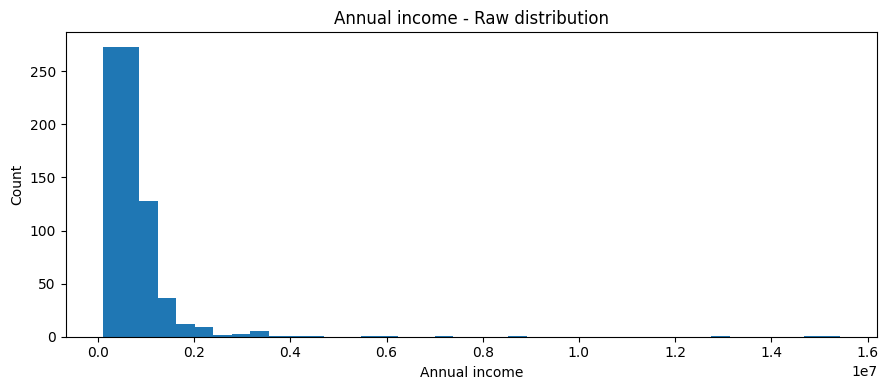

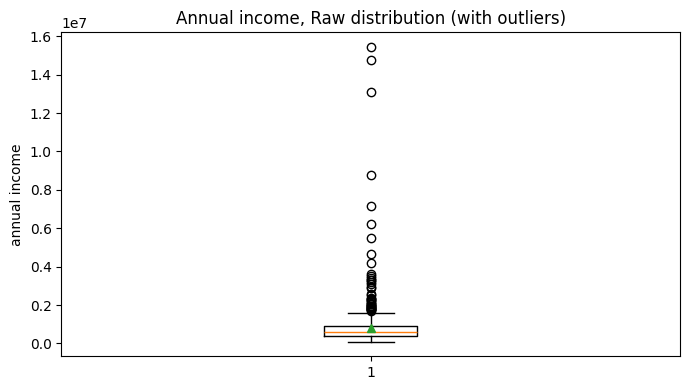

In [20]:
## Visualization
plt.figure(figsize =(9,4))
plt.hist(income_train.dropna(), bins = 40)
plt.title("Annual income - Raw distribution")
plt.xlabel("Annual income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize = (7,4))
plt.boxplot(income_train.dropna(), showmeans=True)
plt.title("Annual income, Raw distribution (with outliers)")
plt.ylabel("annual income")
plt.tight_layout()
plt.show()

In [ ]:
## We're going to build two basic approaches --> 
##   A) baseline = standard preprocessing using SimpleImputer and Scaler
##   B) Normalized method = special transformation on Annual_income only